In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def load_keel_file(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
    data_start = False
    data = []
    for line in lines:
        line = line.strip()
        if line.startswith("@data"):
            data_start = True
            continue
        if data_start and line:
            data.append(line.split(","))
    return pd.DataFrame(data)


In [ ]:
import numpy as np
from numpy.linalg import norm
from cvxopt import matrix, solvers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import defaultdict


In [ ]:
def prepare_keel_data(file_path):
    df = load_keel_file(file_path)
    X = df.iloc[:, :-1].astype(float).values
    y_raw = df.iloc[:, -1].astype(str)
    classes = sorted(y_raw.unique())
    y_map = {classes[0]: -1, classes[1]: 1}
    y = y_raw.map(y_map).values
    X = StandardScaler().fit_transform(X)
    return X, y

# HINGE

In [ ]:
def compute_bias(X, y, alpha_eff, support_threshold=1e-4):
    support_indices = np.where(np.abs(alpha_eff) > support_threshold)[0]
    if len(support_indices) == 0:
        return 0.0
    X_sv = X[support_indices]
    y_sv = y[support_indices]
    alpha_sv = alpha_eff[support_indices]
    b_values = []
    for i in support_indices:
        k = X_sv @ X[i]
        margin = np.sum(alpha_sv * y_sv * k)
        b_values.append(y[i] - margin)
    return np.mean(b_values) if b_values else 0.0

def compute_angle_deviation(w1, w2):
    if norm(w1) == 0 or norm(w2) == 0:
        return None
    cos_sim = np.dot(w1, w2) / (norm(w1) * norm(w2))
    cos_sim = np.clip(cos_sim, -1.0, 1.0)
    return np.degrees(np.arccos(cos_sim))

In [ ]:
import numpy as np
from cvxopt import matrix, solvers

In [ ]:
def hinge_svm_dual(X, y, C=1.0):
    n_samples = X.shape[0]
    K = X @ X.T
    Y = y.reshape(-1, 1)
    Q = (Y @ Y.T) * K

    P = matrix(Q)
    q = matrix(-np.ones(n_samples))
    G = matrix(np.vstack([-np.eye(n_samples), np.eye(n_samples)]))
    h = matrix(np.hstack([np.zeros(n_samples), np.ones(n_samples) * C]))
    A = matrix(y.reshape(1, -1).astype('double'))
    b_qp = matrix(np.array([0.0]))

    solvers.options['show_progress'] = False
    sol = solvers.qp(P, q, G, h, A, b_qp)

    if sol['status'] != 'optimal':
        return None, None

    alpha = np.array(sol['x']).flatten()
    b = compute_bias(X, y, alpha)
    return alpha, b

def get_weight_vector(X, y, alpha):
    return np.sum((alpha * y)[:, None] * X, axis=0)

def train_hinge_svm(X, y, C=1.0):
    alpha, b = hinge_svm_dual(X, y, C)
    if alpha is None:
        return None, None, None
    w = get_weight_vector(X, y, alpha)
    if np.any(np.isnan(w)) or np.all(w == 0):
        return None, None, None
    return alpha, b, w

In [ ]:
from collections import defaultdict
import numpy as np

C_exp_range = range(-18, 19, 2)
C_values = [2 ** i for i in C_exp_range]
dataset_paths = {
    "heart": {
        "standard": "/content/heart_standard.dat",
        "class_noise": "/content/heart_class_noise.dat",
        "attribute_noise": "/content/heart_attribute_noise.dat"
    },
    "pima": {
        "standard": "/content/pima_standard.dat",
        "class_noise": "/content/pima_class_noise.dat",
        "attribute_noise": "/content/pima_attribute_noise.dat"
    },
    "ionosphere": {
        "standard": "/content/ionosphere_standard.dat",
        "class_noise": "/content/ionosphere_class_noise.dat",
        "attribute_noise": "/content/ionosphere_attribute_noise.dat"
    },

    "sonar": {
        "standard": "/content/sonar_standard.dat",
        "class_noise": "/content/sonar_class_noise.dat",
        "attribute_noise": "/content/sonar_attribute_noise.dat"
    }
}


results_class_noise = defaultdict(dict)
results_attribute_noise = defaultdict(dict)


for name, paths in dataset_paths.items():
    print(f"\nProcessing dataset: {name}")

    # Load datasets
    X_std, y_std = prepare_keel_data(paths["standard"])
    X_cls, y_cls = prepare_keel_data(paths["class_noise"])
    X_att, y_att = prepare_keel_data(paths["attribute_noise"])

    for C in C_values:
        try:
            _, _, w_std = train_hinge_svm(X_std, y_std, C)
            _, _, w_cls = train_hinge_svm(X_cls, y_cls, C)
            _, _, w_att = train_hinge_svm(X_att, y_att, C)

            # Angular deviations
            angle_cls = compute_angle_deviation(w_std, w_cls) if w_std is not None and w_cls is not None else None
            angle_att = compute_angle_deviation(w_std, w_att) if w_std is not None and w_att is not None else None

        except Exception as e:
            print(f"Error for dataset {name}, C={C}: {e}")
            angle_cls, angle_att = None, None

        results_class_noise[name][C] = angle_cls
        results_attribute_noise[name][C] = angle_att



Processing dataset: heart

Processing dataset: pima

Processing dataset: ionosphere

Processing dataset: sonar


In [ ]:
from tabulate import tabulate

print("\n=== Best C per Dataset (Standard vs Class Noise) ===")
table = []
headers = ["Dataset", "Best C", "Min Angular Deviation (°)"]

for name in dataset_paths:
    best_C, best_angle = None, float("inf")
    for C, angle in results_class_noise[name].items():
        if angle is not None and angle < best_angle:
            best_C, best_angle = C, angle

    table.append([
        name.title(),
        f"{best_C:.1e}" if best_C else "N/A",
        f"{best_angle:.2f}" if best_C else "N/A"
    ])

print(tabulate(table, headers=headers, tablefmt="fancy_grid"))





=== Best C per Dataset (Standard vs Class Noise) ===
╒════════════╤══════════╤═════════════════════════════╕
│ Dataset    │   Best C │   Min Angular Deviation (°) │
╞════════════╪══════════╪═════════════════════════════╡
│ Heart      │  3.8e-06 │                           0 │
├────────────┼──────────┼─────────────────────────────┤
│ Pima       │  3.8e-06 │                           0 │
├────────────┼──────────┼─────────────────────────────┤
│ Ionosphere │  3.8e-06 │                           0 │
├────────────┼──────────┼─────────────────────────────┤
│ Sonar      │  6.1e-05 │                           0 │
╘════════════╧══════════╧═════════════════════════════╛


In [ ]:
print("\n=== Best C per Dataset (Standard vs Attribute Noise) ===")
table = []

for name in dataset_paths:
    best_C, best_angle = None, float("inf")
    for C, angle in results_attribute_noise[name].items():
        if angle is not None and angle < best_angle:
            best_C, best_angle = C, angle

    table.append([
        name.title(),
        f"{best_C:.1e}" if best_C else "N/A",
        f"{best_angle:.2f}" if best_C else "N/A"
    ])

print(tabulate(table, headers=headers, tablefmt="fancy_grid"))



=== Best C per Dataset (Standard vs Attribute Noise) ===
╒════════════╤══════════╤═════════════════════════════╕
│ Dataset    │   Best C │   Min Angular Deviation (°) │
╞════════════╪══════════╪═════════════════════════════╡
│ Heart      │  3.8e-06 │                        3.76 │
├────────────┼──────────┼─────────────────────────────┤
│ Pima       │  3.8e-06 │                        9.03 │
├────────────┼──────────┼─────────────────────────────┤
│ Ionosphere │  3.8e-06 │                        7.3  │
├────────────┼──────────┼─────────────────────────────┤
│ Sonar      │  0.00098 │                       11.98 │
╘════════════╧══════════╧═════════════════════════════╛


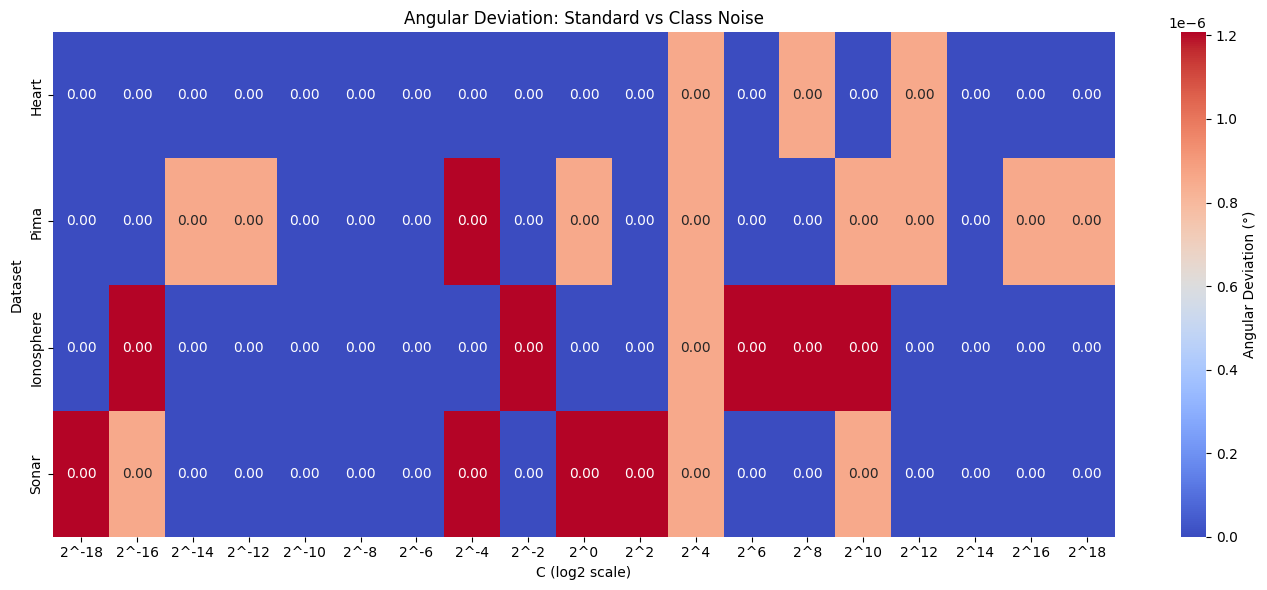

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import os

heatmap_class = pd.DataFrame(
    index=[name.title() for name in dataset_paths],
    columns=[f"2^{i}" for i in C_exp_range]
)

for i, C in enumerate(C_values):
    for name in dataset_paths:
        heatmap_class.loc[name.title(), f"2^{C_exp_range[i]}"] = results_class_noise[name][C]

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_class.astype(float), annot=True, fmt=".2f",
            cmap="coolwarm", cbar_kws={"label": "Angular Deviation (°)"})
plt.title("Angular Deviation: Standard vs Class Noise")
plt.xlabel("C (log2 scale)")
plt.ylabel("Dataset")
plt.tight_layout()

os.makedirs("hinge_heatmaps", exist_ok=True)
plt.savefig("hinge_heatmaps/hinge_svm_class_noise_heatmap.png", dpi=300)
plt.show()

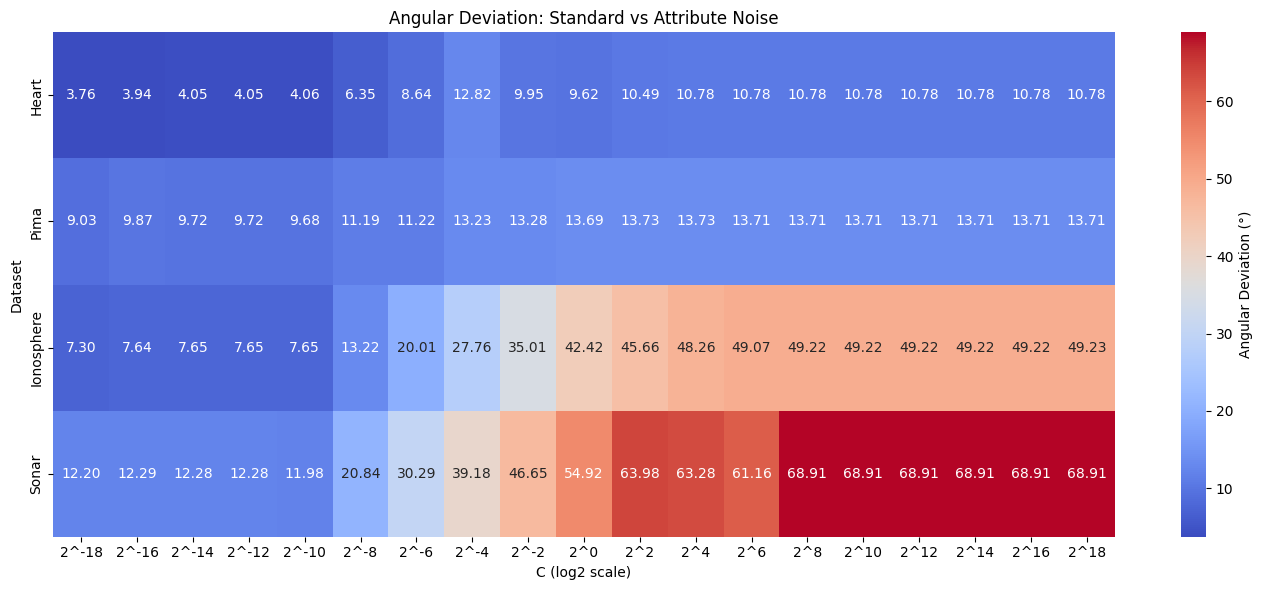

In [ ]:
heatmap_attribute = pd.DataFrame(
    index=[name.title() for name in dataset_paths],
    columns=[f"2^{i}" for i in C_exp_range]
)

for i, C in enumerate(C_values):
    for name in dataset_paths:
        heatmap_attribute.loc[name.title(), f"2^{C_exp_range[i]}"] = results_attribute_noise[name][C]

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_attribute.astype(float), annot=True, fmt=".2f",
            cmap="coolwarm", cbar_kws={"label": "Angular Deviation (°)"})
plt.title("Angular Deviation: Standard vs Attribute Noise")
plt.xlabel("C (log2 scale)")
plt.ylabel("Dataset")
plt.tight_layout()
plt.savefig("hinge_heatmaps/hinge_svm_attribute_noise_heatmap.png", dpi=300)
plt.show()


# PINBALL

In [ ]:
def pinball_svm_dual(X, y, C=1.0, tau=0.5, kernel='linear'):
    n = X.shape[0]

    if kernel == 'linear':
        K = X @ X.T
    else:
        raise NotImplementedError("Only linear kernel is implemented")

    Y = y.reshape(-1, 1)
    Q = (Y @ Y.T) * K

    H = np.block([
        [ Q, -Q ],
        [ -Q, Q ]
    ])

    c = np.hstack([-1 * np.ones(n), 1 * np.ones(n)])

    Aeq = np.hstack([y, -y]).reshape(1, -1)
    beq = np.array([0.0])

    A2 = np.zeros((n, 2*n))
    A2[np.arange(n), np.arange(n)] = 1
    A2[np.arange(n), np.arange(n) + n] = 1/tau
    b2 = np.ones(n) * C

    A_combined = np.vstack([Aeq, A2])
    b_combined = np.hstack([beq, b2])

    A = matrix(A_combined.astype(np.float64))
    b = matrix(b_combined.astype(np.float64))


    G = -np.eye(2 * n)
    h = np.zeros(2 * n)

    P = matrix(H)
    q = matrix(c)
    G = matrix(G)
    h = matrix(h)
    A = matrix(A_combined)
    b = matrix(b_combined)

    solvers.options['show_progress'] = False
    sol = solvers.qp(P, q, G, h, A, b)

    result = np.array(sol['x']).flatten()
    alpha, beta = result[:n], result[n:]
    return alpha, beta


In [ ]:
def get_weight_vector_pinball(X, y, alpha, beta):
    return np.sum(((alpha - beta) * y)[:, None] * X, axis=0)

def train_pinball_svm(X, y, C=1.0, tau=0.5):
    alpha, beta = pinball_svm_dual(X, y, C, tau)
    if alpha is None or beta is None:
        return None, None, None
    w = get_weight_vector_pinball(X, y, alpha, beta)
    margin_indices = np.where((alpha > 1e-5) | (beta > 1e-5))[0]
    if len(margin_indices) == 0:
        b = 0.0
    else:
        b_vals = []
        for i in margin_indices:
            b_i = y[i] - np.dot(w, X[i])
            b_vals.append(b_i)
        b = np.mean(b_vals)

    return alpha, beta, w, b


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

C_exp_range = range(-18, 19, 2)
C_values = [2 ** i for i in C_exp_range]
tau_values = np.round(np.arange(0.1, 1.0 + 0.1, 0.1), 2)

dataset_paths = {
    "heart": {
        "standard": "/content/heart_standard.dat",
        "class_noise": "/content/heart_class_noise.dat",
        "attribute_noise": "/content/heart_attribute_noise.dat"
    },
    "pima": {
        "standard": "/content/pima_standard.dat",
        "class_noise": "/content/pima_class_noise.dat",
        "attribute_noise": "/content/pima_attribute_noise.dat"
    },
    "ionosphere": {
        "standard": "/content/ionosphere_standard.dat",
        "class_noise": "/content/ionosphere_class_noise.dat",
        "attribute_noise": "/content/ionosphere_attribute_noise.dat"
    },

    "sonar": {
        "standard": "/content/sonar_standard.dat",
        "class_noise": "/content/sonar_class_noise.dat",
        "attribute_noise": "/content/sonar_attribute_noise.dat"
    }
}


results_class_noise = {}
results_attribute_noise = {}


for name, paths in dataset_paths.items():
    print(f"\nProcessing dataset: {name}")

    X_std, y_std = prepare_keel_data(paths["standard"])
    X_cls, y_cls = prepare_keel_data(paths["class_noise"])
    X_att, y_att = prepare_keel_data(paths["attribute_noise"])

    results_class_noise[name] = {}
    results_attribute_noise[name] = {}

    for C in C_values:
        for tau in tau_values:
            try:
                _, _, w_std, _ = train_pinball_svm(X_std, y_std, C=C, tau=tau)
                _, _, w_cls, _ = train_pinball_svm(X_cls, y_cls, C=C, tau=tau)
                _, _, w_att, _ = train_pinball_svm(X_att, y_att, C=C, tau=tau)

                angle_cls = compute_angle_deviation(w_std, w_cls) if w_std is not None and w_cls is not None else None
                angle_att = compute_angle_deviation(w_std, w_att) if w_std is not None and w_att is not None else None

            except Exception as e:
                print(f"{name} | C={C:.1e}, τ={tau}: {e}")
                angle_cls, angle_att = None, None

            results_class_noise[name][(C, tau)] = angle_cls
            results_attribute_noise[name][(C, tau)] = angle_att



Processing dataset: heart

Processing dataset: pima

Processing dataset: ionosphere

Processing dataset: sonar


In [ ]:
from tabulate import tabulate

print("\n=== Best Hyperparameters (Standard vs Class Noise) ===")
table = []
headers = ["Dataset", "Best C", "Best τ", "Min Angular Deviation (°)"]

for name in dataset_paths:
    best_C, best_tau, min_angle = None, None, float("inf")

    for (C, tau), angle in results_class_noise[name].items():
        if angle is not None and angle < min_angle:
            best_C, best_tau, min_angle = C, tau, angle

    table.append([
        name.title(),
        f"{best_C:.1e}" if best_C else "N/A",
        f"{best_tau:.2f}" if best_tau else "N/A",
        f"{min_angle:.2f}" if best_C else "N/A"
    ])

print(tabulate(table, headers=headers, tablefmt="fancy_grid"))




=== Best Hyperparameters (Standard vs Class Noise) ===
╒════════════╤══════════╤══════════╤═════════════════════════════╕
│ Dataset    │   Best C │   Best τ │   Min Angular Deviation (°) │
╞════════════╪══════════╪══════════╪═════════════════════════════╡
│ Heart      │  3.8e-06 │      0.1 │                           0 │
├────────────┼──────────┼──────────┼─────────────────────────────┤
│ Pima       │  3.8e-06 │      0.1 │                           0 │
├────────────┼──────────┼──────────┼─────────────────────────────┤
│ Ionosphere │  3.8e-06 │      0.2 │                           0 │
├────────────┼──────────┼──────────┼─────────────────────────────┤
│ Sonar      │  3.8e-06 │      0.1 │                           0 │
╘════════════╧══════════╧══════════╧═════════════════════════════╛


In [ ]:
print("\n=== Best Hyperparameters (Standard vs Attribute Noise) ===")
table = []

for name in dataset_paths:
    best_C, best_tau, min_angle = None, None, float("inf")

    for (C, tau), angle in results_attribute_noise[name].items():
        if angle is not None and angle < min_angle:
            best_C, best_tau, min_angle = C, tau, angle

    table.append([
        name.title(),
        f"{best_C:.1e}" if best_C else "N/A",
        f"{best_tau:.2f}" if best_tau else "N/A",
        f"{min_angle:.2f}" if best_C else "N/A"
    ])

print(tabulate(table, headers=headers, tablefmt="fancy_grid"))



=== Best Hyperparameters (Standard vs Attribute Noise) ===
╒════════════╤══════════╤══════════╤═════════════════════════════╕
│ Dataset    │   Best C │   Best τ │   Min Angular Deviation (°) │
╞════════════╪══════════╪══════════╪═════════════════════════════╡
│ Heart      │ 16       │      1   │                        0    │
├────────────┼──────────┼──────────┼─────────────────────────────┤
│ Pima       │  0.016   │      0.6 │                       10    │
├────────────┼──────────┼──────────┼─────────────────────────────┤
│ Ionosphere │  3.8e-06 │      0.1 │                        7.36 │
├────────────┼──────────┼──────────┼─────────────────────────────┤
│ Sonar      │  0.00098 │      0.1 │                       12.36 │
╘════════════╧══════════╧══════════╧═════════════════════════════╛


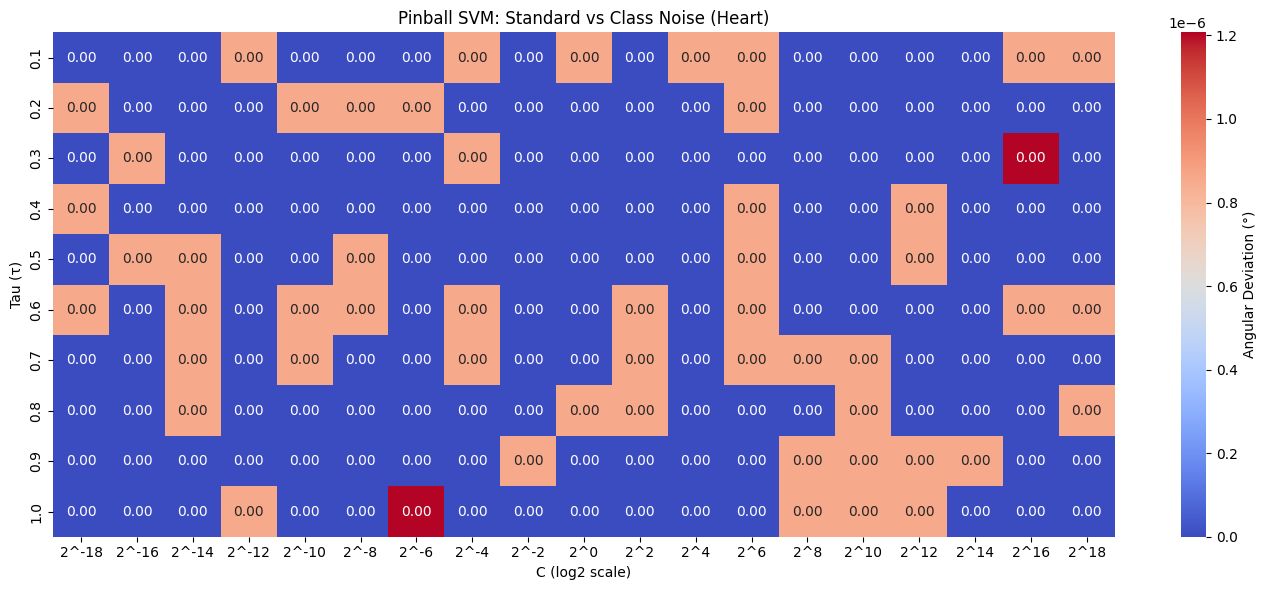

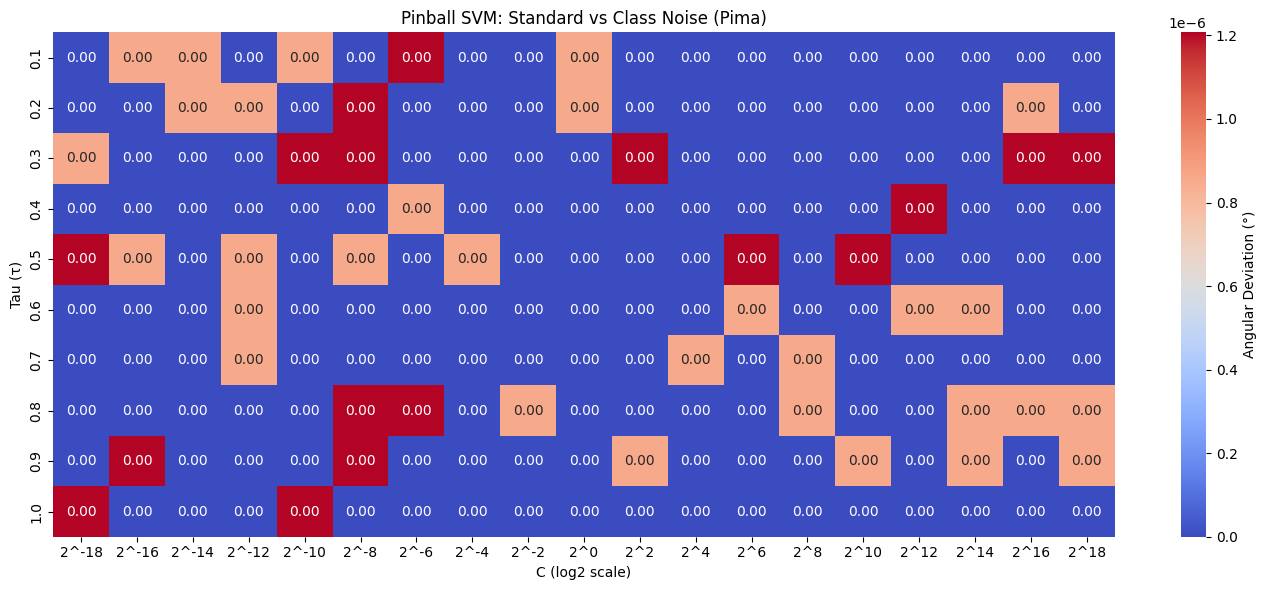

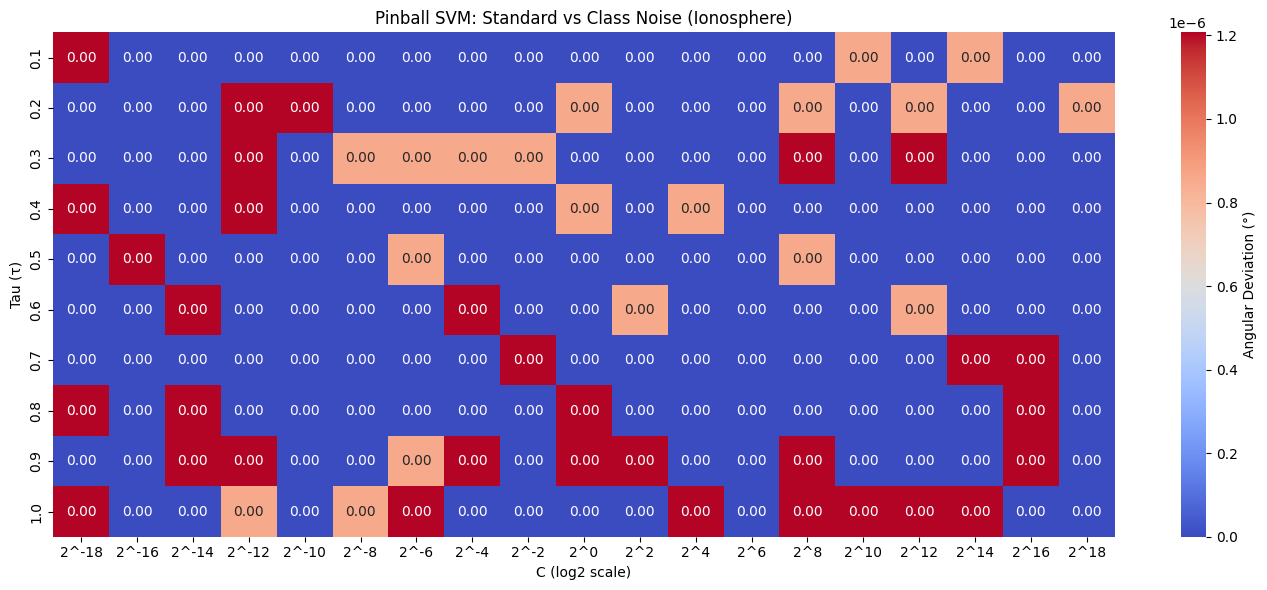

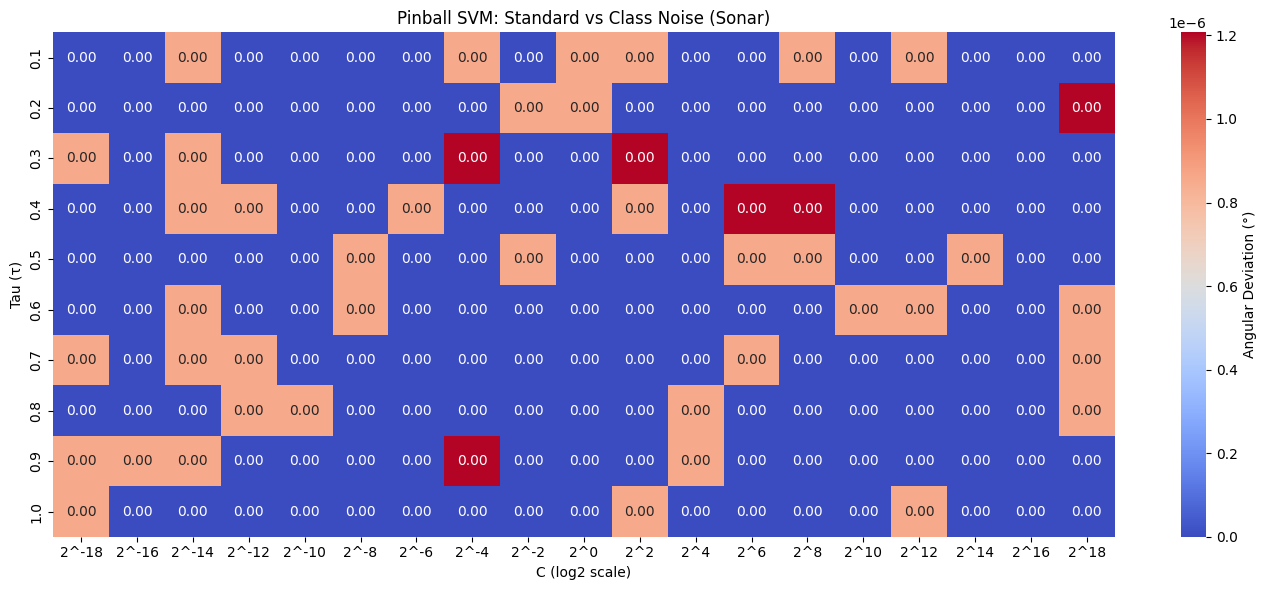

In [ ]:
import seaborn as sns
import pandas as pd

for name in dataset_paths:
    heatmap_df = pd.DataFrame(
        index=[f"{tau:.1f}" for tau in tau_values],
        columns=[f"2^{exp}" for exp in C_exp_range]
    )

    for i, C in enumerate(C_values):
        for tau in tau_values:
            heatmap_df.iloc[tau_values.tolist().index(tau), i] = \
                results_class_noise[name].get((C, tau))

    plt.figure(figsize=(14, 6))
    sns.heatmap(heatmap_df.astype(float), annot=True, fmt=".2f",
                cmap="coolwarm", cbar_kws={"label": "Angular Deviation (°)"})
    plt.title(f"Pinball SVM: Standard vs Class Noise ({name.title()})")
    plt.xlabel("C (log2 scale)")
    plt.ylabel("Tau (τ)")
    plt.tight_layout()
    os.makedirs("pinball_heatmaps", exist_ok=True)
    plt.savefig(f"pinball_heatmaps/pinball_class_noise_{name}.png", dpi=300)
    plt.show()



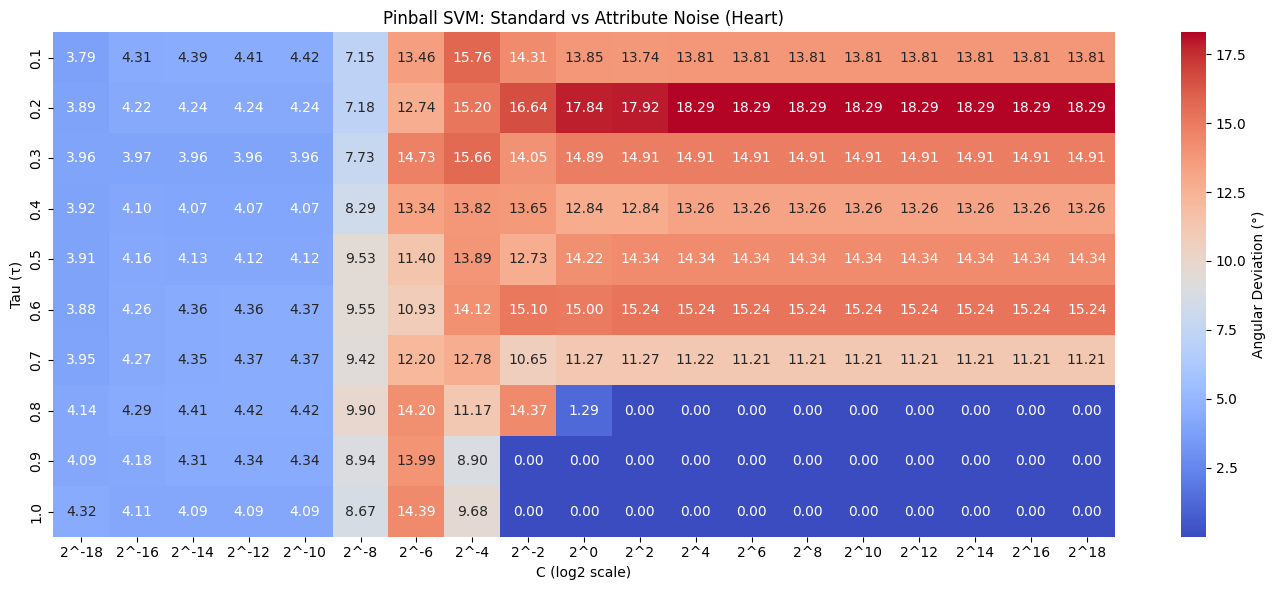

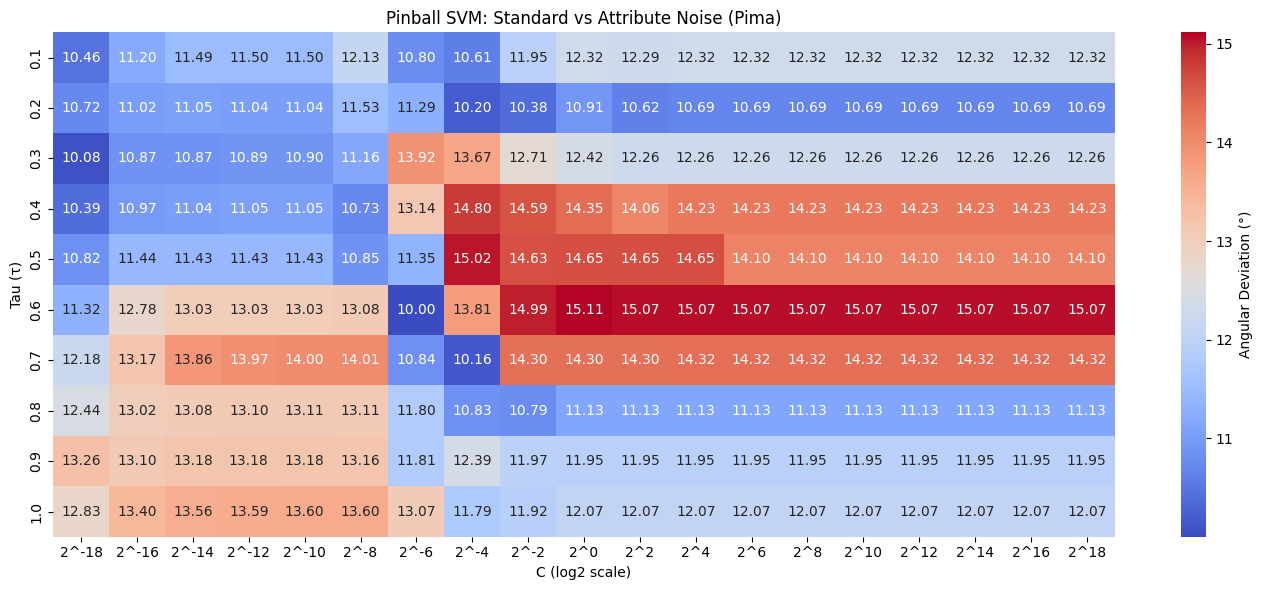

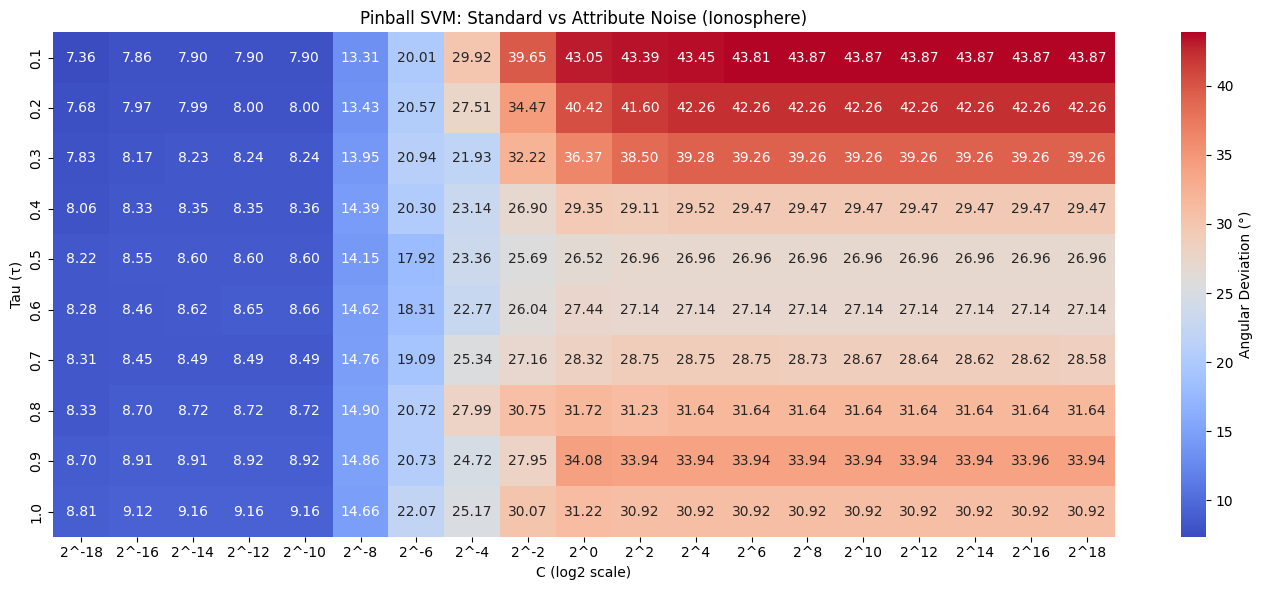

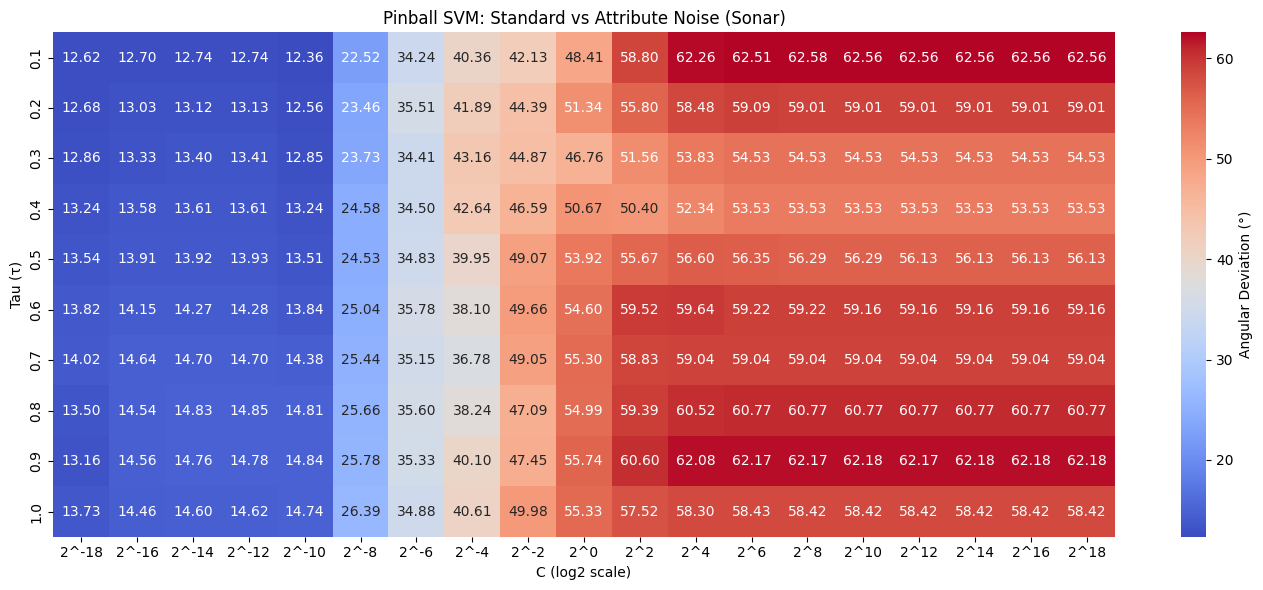

In [ ]:
for name in dataset_paths:
    heatmap_df = pd.DataFrame(
        index=[f"{tau:.1f}" for tau in tau_values],
        columns=[f"2^{exp}" for exp in C_exp_range]
    )

    for i, C in enumerate(C_values):
        for tau in tau_values:
            heatmap_df.iloc[tau_values.tolist().index(tau), i] = \
                results_attribute_noise[name].get((C, tau))

    plt.figure(figsize=(14, 6))
    sns.heatmap(heatmap_df.astype(float), annot=True, fmt=".2f",
                cmap="coolwarm", cbar_kws={"label": "Angular Deviation (°)"})
    plt.title(f"Pinball SVM: Standard vs Attribute Noise ({name.title()})")
    plt.xlabel("C (log2 scale)")
    plt.ylabel("Tau (τ)")
    plt.tight_layout()
    plt.savefig(f"pinball_heatmaps/pinball_attribute_noise_{name}.png", dpi=300)
    plt.show()


# Eagle

In [ ]:
def eagle_svm_dual(X, y, C=1.0, tau=0.5, psi1=2.5, psi2=1.5):
    n = X.shape[0]
    y = y.reshape(-1, 1)

    K = X @ X.T
    Q = (y @ y.T) * K

    H = np.block([
        [ Q, -Q ],
        [ -Q, Q ]
    ])

    c_alpha = -(psi1 - 1) * np.ones(n)
    c_beta = -(1 - psi2) * np.ones(n)
    c = np.hstack([c_alpha, c_beta])

    Aeq = np.hstack([y.T, -y.T])
    beq = np.array([0.0])

    A2 = np.zeros((n, 2 * n))
    A2[np.arange(n), np.arange(n)] = 1
    A2[np.arange(n), np.arange(n) + n] = 1
    b2 = np.ones(n) * C * tau

    A_combined = np.vstack([Aeq, A2])
    b_combined = np.hstack([beq, b2])

    G = -np.eye(2 * n)
    h = np.zeros(2 * n)

    P = matrix(H)
    q = matrix(c)
    G = matrix(G)
    h = matrix(h)
    A = matrix(A_combined)
    b = matrix(b_combined)

    solvers.options['show_progress'] = False
    sol = solvers.qp(P, q, G, h, A, b)

    result = np.array(sol['x']).flatten()
    alpha = result[:n]
    beta = result[n:]

    return alpha, beta

In [ ]:
def get_weight_vector_eagle(X, y, alpha, beta):
    return np.sum(((alpha - beta) * y)[:, None] * X, axis=0)

def train_eagle_svm(X, y, C=1.0, tau=0.5, psi1=2.5, psi2=1.5):
    alpha, beta = eagle_svm_dual(X, y, C, tau, psi1, psi2)

    if alpha is None or beta is None:
        return None, None, None, None

    w = get_weight_vector_eagle(X, y, alpha, beta)

    margin_indices = np.where((alpha > 1e-5) | (beta > 1e-5))[0]
    if len(margin_indices) == 0:
        b = 0.0
    else:
        b_vals = []
        for i in margin_indices:
            b_i = y[i] - np.dot(w, X[i])
            b_vals.append(b_i)
        b = np.mean(b_vals)

    return alpha, beta, w, b


In [ ]:
C_values = [2**i for i in range(-18, 19, 4)]
tau_values = np.round(np.arange(0.1, 1.0 + 0.1, 0.2), 2)
psi1_values = np.round(np.arange(1.0, 3.1, 0.5), 1).tolist()
psi2_values = np.round(np.arange(1.0, 3.1, 0.5), 1).tolist()


In [ ]:
results_eagle_class_noise = {}
results_eagle_attribute_noise = {}

In [ ]:
dataset_paths = {
    "heart": {
        "standard": "/content/heart_standard.dat",
        "class_noise": "/content/heart_class_noise.dat",
        "attribute_noise": "/content/heart_attribute_noise.dat"
    },
    "pima": {
        "standard": "/content/pima_standard.dat",
        "class_noise": "/content/pima_class_noise.dat",
        "attribute_noise": "/content/pima_attribute_noise.dat"
    },
    "ionosphere": {
        "standard": "/content/ionosphere_standard.dat",
        "class_noise": "/content/ionosphere_class_noise.dat",
        "attribute_noise": "/content/ionosphere_attribute_noise.dat"
    },

    "sonar": {
        "standard": "/content/sonar_standard.dat",
        "class_noise": "/content/sonar_class_noise.dat",
        "attribute_noise": "/content/sonar_attribute_noise.dat"
    }
}



for name, paths in dataset_paths.items():
    print(f"\nProcessing dataset: {name}")

    X_std, y_std = prepare_keel_data(paths["standard"])
    X_cls, y_cls = prepare_keel_data(paths["class_noise"])
    X_att, y_att = prepare_keel_data(paths["attribute_noise"])

    results_eagle_class_noise[name] = {}
    results_eagle_attribute_noise[name] = {}

    for C in C_values:
        for tau in tau_values:
            for psi1 in psi1_values:
                for psi2 in psi2_values:
                    try:
                        _, _, w_std, _ = train_eagle_svm(X_std, y_std, C, tau, psi1, psi2)
                        _, _, w_cls, _ = train_eagle_svm(X_cls, y_cls, C, tau, psi1, psi2)
                        _, _, w_att, _ = train_eagle_svm(X_att, y_att, C, tau, psi1, psi2)

                        angle_cls = compute_angle_deviation(w_std, w_cls) \
                            if w_std is not None and w_cls is not None else None

                        angle_att = compute_angle_deviation(w_std, w_att) \
                            if w_std is not None and w_att is not None else None

                    except Exception as e:
                        angle_cls, angle_att = None, None

                    results_eagle_class_noise[name][(C, tau, psi1, psi2)] = angle_cls
                    results_eagle_attribute_noise[name][(C, tau, psi1, psi2)] = angle_att




Processing dataset: pima


In [ ]:
from tabulate import tabulate

print("\n=== Best Eagle Hyperparameters (Standard vs Class Noise) ===")

table = [["Dataset", "C", "Tau", "Psi1", "Psi2", "Min Angular Deviation (°)"]]

for name in results_eagle_class_noise:
    best_params = None
    best_angle = float("inf")

    for params, angle in results_eagle_class_noise[name].items():
        if angle is not None and angle < best_angle:
            best_params, best_angle = params, angle

    if best_params:
        C, tau, psi1, psi2 = best_params
        table.append([name, f"{C:.1e}", tau, psi1, psi2, f"{best_angle:.2f}"])
    else:
        table.append([name, "-", "-", "-", "-", "N/A"])

print(tabulate(table, headers="firstrow", tablefmt="grid"))




=== Best Eagle Hyperparameters (Standard vs Class Noise) ===
+-----------+---------+-------+--------+--------+-----------------------------+
| Dataset   |       C |   Tau |   Psi1 |   Psi2 |   Min Angular Deviation (°) |
+===========+=========+=======+========+========+=============================+
| pima      | 3.8e-06 |   0.1 |      1 |      1 |                           0 |
+-----------+---------+-------+--------+--------+-----------------------------+


In [ ]:
print("\n=== Best Eagle Hyperparameters (Standard vs Attribute Noise) ===")

table = [["Dataset", "C", "Tau", "Psi1", "Psi2", "Min Angular Deviation (°)"]]

for name in results_eagle_attribute_noise:
    best_params = None
    best_angle = float("inf")

    for params, angle in results_eagle_attribute_noise[name].items():
        if angle is not None and angle < best_angle:
            best_params, best_angle = params, angle

    if best_params:
        C, tau, psi1, psi2 = best_params
        table.append([name, f"{C:.1e}", tau, psi1, psi2, f"{best_angle:.2f}"])
    else:
        table.append([name, "-", "-", "-", "-", "N/A"])

print(tabulate(table, headers="firstrow", tablefmt="grid"))



=== Best Eagle Hyperparameters (Standard vs Attribute Noise) ===
+-----------+---------+-------+--------+--------+-----------------------------+
| Dataset   |       C |   Tau |   Psi1 |   Psi2 |   Min Angular Deviation (°) |
+===========+=========+=======+========+========+=============================+
| pima      | 3.8e-06 |   0.1 |      2 |      2 |                        5.85 |
+-----------+---------+-------+--------+--------+-----------------------------+


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs("eagle_heatmaps_class_noise", exist_ok=True)

for name in results_eagle_class_noise:
    best_combo, best_angle = None, float("inf")

    for (C, tau, psi1, psi2), angle in results_eagle_class_noise[name].items():
        if angle is not None and angle < best_angle:
            best_combo, best_angle = (psi1, psi2), angle

    if best_combo is None:
        continue

    psi1_best, psi2_best = best_combo
    heatmap_data = np.full((len(C_values), len(tau_values)), np.nan)

    for i, C in enumerate(C_values):
        for j, tau in enumerate(tau_values):
            heatmap_data[i, j] = results_eagle_class_noise[name].get(
                (C, tau, psi1_best, psi2_best), np.nan
            )

    plt.figure(figsize=(10, 7))
    sns.heatmap(
        heatmap_data, annot=True, fmt=".2f",
        xticklabels=tau_values,
        yticklabels=[f"2^{i}" for i in range(-18, 19, 4)],
        cmap="coolwarm"
    )

    plt.xlabel("Tau (τ)")
    plt.ylabel("C (log scale)")
    plt.title(f"Eagle SVM: Standard vs Class Noise ({name.title()})\nψ₁={psi1_best}, ψ₂={psi2_best}")
    plt.tight_layout()
    plt.savefig(f"eagle_heatmaps_class_noise/{name}.png", dpi=300)
    plt.close()

In [ ]:
os.makedirs("eagle_heatmaps_attribute_noise", exist_ok=True)

for name in results_eagle_attribute_noise:
    best_combo, best_angle = None, float("inf")

    for (C, tau, psi1, psi2), angle in results_eagle_attribute_noise[name].items():
        if angle is not None and angle < best_angle:
            best_combo, best_angle = (psi1, psi2), angle

    if best_combo is None:
        continue

    psi1_best, psi2_best = best_combo
    heatmap_data = np.full((len(C_values), len(tau_values)), np.nan)

    for i, C in enumerate(C_values):
        for j, tau in enumerate(tau_values):
            heatmap_data[i, j] = results_eagle_attribute_noise[name].get(
                (C, tau, psi1_best, psi2_best), np.nan
            )

    plt.figure(figsize=(10, 7))
    sns.heatmap(
        heatmap_data, annot=True, fmt=".2f",
        xticklabels=tau_values,
        yticklabels=[f"2^{i}" for i in range(-18, 19, 4)],
        cmap="coolwarm"
    )

    plt.xlabel("Tau (τ)")
    plt.ylabel("C (log scale)")
    plt.title(f"Eagle SVM: Standard vs Attribute Noise ({name.title()})\nψ₁={psi1_best}, ψ₂={psi2_best}")
    plt.tight_layout()
    plt.savefig(f"eagle_heatmaps_attribute_noise/{name}.png", dpi=300)
    plt.close()

# Plot datasets

In [ ]:
dataset_paths = {
    "heart": {
        "standard": "/content/heart_standard.dat",
        "class_noise": "/content/heart_class_noise.dat",
        "attribute_noise": "/content/heart_attribute_noise.dat"
    },
    "ionosphere": {
        "standard": "/content/ionosphere_standard.dat",
        "class_noise": "/content/ionosphere_class_noise.dat",
        "attribute_noise": "/content/ionosphere_attribute_noise.dat"
    },
    "sonar": {
        "standard": "/content/sonar_standard.dat",
        "class_noise": "/content/sonar_class_noise.dat",
        "attribute_noise": "/content/sonar_attribute_noise.dat"
    },
    "pima": {
        "standard": "/content/pima_standard.dat",
        "class_noise": "/content/pima_class_noise.dat",
        "attribute_noise": "/content/pima_attribute_noise.dat"
    }
}


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import matplotlib.pyplot as plt

def plot_and_save_single(X, y, title, save_path):
    plt.figure(figsize=(8, 6))

    plt.scatter(
        X[y == -1, 0],
        X[y == -1, 1],
        c="red",
        marker="x",
        label="1 (Negative)",
        alpha=0.8
    )

    plt.scatter(
        X[y == 1, 0],
        X[y == 1, 1],
        c="blue",
        marker="+",
        label="2 (Positive)",
        alpha=0.8
    )

    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.savefig(save_path, dpi=300)
    plt.close()


In [ ]:
BASE_DIR = "/content/drive/MyDrive/dataset_plots"

for dataset_name, paths in dataset_paths.items():
    print(f"Saving plots for {dataset_name}")

    std_dir = os.path.join(BASE_DIR, dataset_name, "standard")
    cls_dir = os.path.join(BASE_DIR, dataset_name, "class_noise")
    att_dir = os.path.join(BASE_DIR, dataset_name, "attribute_noise")

    os.makedirs(std_dir, exist_ok=True)
    os.makedirs(cls_dir, exist_ok=True)
    os.makedirs(att_dir, exist_ok=True)

    X_std, y_std = prepare_keel_data(paths["standard"])
    X_cls, y_cls = prepare_keel_data(paths["class_noise"])
    X_att, y_att = prepare_keel_data(paths["attribute_noise"])

    plot_and_save_single(
        X_std, y_std,
        f"2D Visualization of {dataset_name} (Standard)",
        os.path.join(std_dir, f"{dataset_name}_standard.png")
    )

    plot_and_save_single(
        X_cls, y_cls,
        f"2D Visualization of {dataset_name} (Class Noise)",
        os.path.join(cls_dir, f"{dataset_name}_class_noise.png")
    )

    plot_and_save_single(
        X_att, y_att,
        f"2D Visualization of {dataset_name} (Attribute Noise)",
        os.path.join(att_dir, f"{dataset_name}_attribute_noise.png")
    )


Saving plots for heart
Saving plots for ionosphere
Saving plots for sonar
Saving plots for pima


In [ ]:
from numpy.linalg import norm

def mean_point_distance(X1, X2):
    return np.mean(norm(X1 - X2, axis=1))


In [ ]:
def label_flip_rate(y_std, y_cls):
    return np.mean(y_std != y_cls)


In [ ]:
print("\n=== Standard vs Class Noise Comparison ===")

for name, paths in dataset_paths.items():
    X_std, y_std = prepare_keel_data(paths["standard"])
    X_cls, y_cls = prepare_keel_data(paths["class_noise"])

    geom_diff = mean_point_distance(X_std, X_cls)
    flip_rate = label_flip_rate(y_std, y_cls)

    print(f"\nDataset: {name.title()}")
    print(f"Mean geometric difference: {geom_diff:.4f}")
    print(f"Label flip rate: {flip_rate * 100:.2f}%")



=== Standard vs Class Noise Comparison ===

Dataset: Heart
Mean geometric difference: 0.0000
Label flip rate: 0.00%

Dataset: Ionosphere
Mean geometric difference: 0.0000
Label flip rate: 0.00%

Dataset: Sonar
Mean geometric difference: 0.0000
Label flip rate: 0.00%

Dataset: Pima
Mean geometric difference: 0.0000
Label flip rate: 0.00%
